In [2]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_excel('Dataset for Data Analytics.xlsx')

# 2. Week 1 baseline cleaning
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

# Updated line to prevent the Pandas4Warning
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()

# 3. Select numerical features
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# 4. Generate summary stats table
summary_df = df[num_cols].describe().T
summary_df['median'] = df[num_cols].median()
summary_df['skewness'] = df[num_cols].skew()

# Display summary
print(summary_df[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness']])

              count         mean         std    min       25%   median  \
Quantity     1200.0     2.945833    1.407557   1.00    2.0000    3.000   
UnitPrice    1200.0   356.412750  197.177146  11.39  186.0625  364.210   
ItemsInCart  1200.0     5.485000    2.281983   1.00    4.0000    5.000   
TotalPrice   1200.0  1053.968300  819.856558  11.39  410.5200  823.615   

                  75%      max  skewness  
Quantity        4.000     5.00  0.027922  
UnitPrice     521.570   699.93 -0.026512  
ItemsInCart     7.000    10.00  0.000877  
TotalPrice   1578.475  3456.40  0.891359  


In [3]:
import numpy as np

# Define Outlier Detection Function
def detect_outliers(series):
    # 1. IQR Method
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    iqr_outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    # 2. Z-Score Method
    mean = series.mean()
    std = series.std()
    z_scores = (series - mean) / std
    z_outliers = series[np.abs(z_scores) > 3]
    
    print(f"--- OUTLIER REPORT FOR {series.name} ---")
    print(f"Q1: ${q1:.2f}")
    print(f"Q3: ${q3:.2f}")
    print(f"IQR: ${iqr:.2f}")
    print(f"IQR Bounds: [${lower_bound:.2f}, ${upper_bound:.2f}]")
    print(f"IQR Outliers Count: {len(iqr_outliers)}")
    print(f"Z-Score Outliers Count (|Z| > 3): {len(z_outliers)}")

# Run detection on TotalPrice
detect_outliers(df['TotalPrice'])

--- OUTLIER REPORT FOR TotalPrice ---
Q1: $410.52
Q3: $1578.47
IQR: $1167.95
IQR Bounds: [$-1341.41, $3330.41]
IQR Outliers Count: 8
Z-Score Outliers Count (|Z| > 3): 0


--- PEARSON CORRELATION MATRIX ---
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity       1.0000     0.0146       0.6501      0.6153
UnitPrice      0.0146     1.0000       0.0006      0.7171
ItemsInCart    0.6501     0.0006       1.0000      0.3925
TotalPrice     0.6153     0.7171       0.3925      1.0000


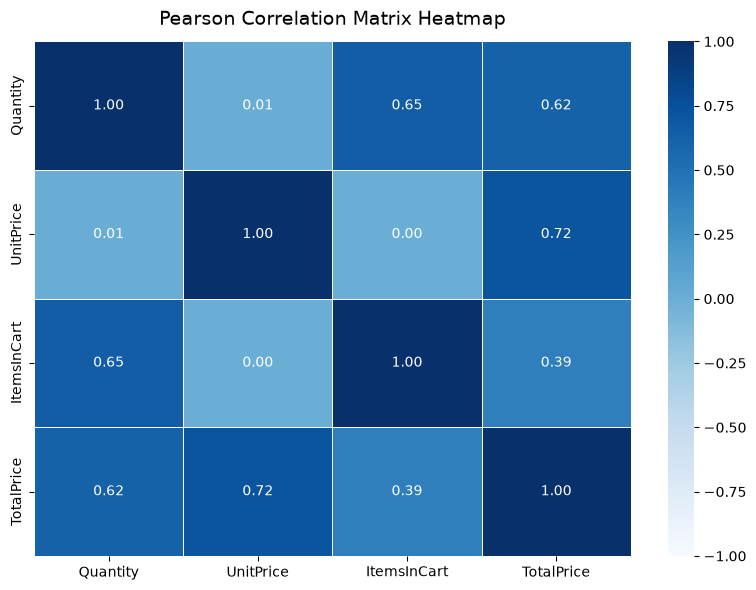

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numerical features for correlation analysis
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# 2. Compute Pearson Correlation Matrix
corr_matrix = df[num_cols].corr(method='pearson')

print("--- PEARSON CORRELATION MATRIX ---")
print(corr_matrix.round(4))

# 3. Plot Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Pearson Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()